# UAV Simulator: быстрый demo-ноутбук

Этот ноутбук сделан под сценарий "запусти сверху вниз и посмотри, как работает симулятор".

Перед запуском:
- запусти Unity: `make sim-public`
- открой сцену `Assets/Scenes/PresentationTrack.unity`
- нажми `Play`
- (опционально для ROS UI) `make demo-up`


In [1]:
# Если пакеты уже стоят, ячейка просто быстро завершится
%pip install -q requests numpy matplotlib pillow

import base64
import io
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Находим корень репозитория (чтобы импортировать python/sim_client)
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "Makefile").exists() and (p / "python").exists():
            return p
    raise RuntimeError("Не найден корень репозитория с Makefile/python")

repo_root = find_repo_root(Path.cwd())
python_dir = repo_root / "python"
if str(python_dir) not in os.sys.path:
    os.sys.path.insert(0, str(python_dir))

from sim_client.http_client import SimClient

# Настройки demo (можно менять под нужный сценарий):
# - UAVSIM_BASE_URL: адрес Unity HTTP API
# - UAVSIM_TRACK_ID: id трека для reset
# - UAVSIM_VEHICLE_ID: id машинки/робота для reset
# - UAVSIM_DEMO_STEPS: длина rollout в шагах
#
# Примеры перед запуском ноутбука:
# export UAVSIM_TRACK_ID="track.basic_arena.v1"
# export UAVSIM_TRACK_ID="track.roadsystem_arena.v1"
# export UAVSIM_VEHICLE_ID="vehicle.ks0223.v1"
# export UAVSIM_VEHICLE_ID="vehicle.drone.simple.v1"

BASE_URL = os.getenv("UAVSIM_BASE_URL", "http://127.0.0.1:8000")
VEHICLE_ID = os.getenv("UAVSIM_VEHICLE_ID", "vehicle.ks0223.v1")
TRACK_ID = os.getenv("UAVSIM_TRACK_ID", "track.basic_arena.v1")
RUN_STEPS = int(os.getenv("UAVSIM_DEMO_STEPS", "80"))

client = SimClient(base_url=BASE_URL, timeout_s=10.0)
print("BASE_URL:", BASE_URL)
print("VEHICLE_ID:", VEHICLE_ID)
print("TRACK_ID:", TRACK_ID)
print("RUN_STEPS:", RUN_STEPS)


Note: you may need to restart the kernel to use updated packages.


BASE_URL: http://127.0.0.1:8000
VEHICLE_ID: vehicle.ks0223.v1
TRACK_ID: track.basic_arena.v1
RUN_STEPS: 80


## 1) Проверка API и reset

Ячейка делает:
- `health`
- `contract` (краткая сводка)
- `reset` на выбранный `vehicle/track`


In [2]:
api_ready = True

try:
    health = client.health()
    print("health:", health)
except Exception as e:
    api_ready = False
    print("API недоступен:", e)
    print("Проверь: Unity в Play, запущено `make sim-public`.")

if api_ready:
    contract = client.get_contract()
    vehicles = contract.get("availableVehicles") or []
    tracks = contract.get("availableTracks") or []
    print(f"contract: vehicles={len(vehicles)}, tracks={len(tracks)}")
    print("sample vehicle ids:", [v.get("vehicleId") for v in vehicles[:5]])
    print("sample track ids  :", [t.get("trackId") for t in tracks[:5]])

    reset_cfg = {
        "seed": 1,
        "timeScale": 1.0,
        "selectedTrackId": TRACK_ID,
        "selectedVehicleId": VEHICLE_ID,
        "trackParams": [],
        "vehicleParams": [],
        "flags": [],
    }
    reset_result = client.reset(reset_cfg)
    print("reset ok:", {k: reset_result.get(k) for k in ["ok", "message", "episodeId"] if k in reset_result})


health: {'status': 'ok'}
contract: vehicles=1, tracks=1
sample vehicle ids: [None]
sample track ids  : ['track.basic_arena.v1']
reset ok: {}


## 2) Прогон `step` + графики + кадры камеры

Ячейка выполняет короткий rollout и показывает:
- скорость по шагам
- steer/throttle/brake по шагам
- несколько кадров фронтальной камеры


rollout done: steps=80, snapshots=3


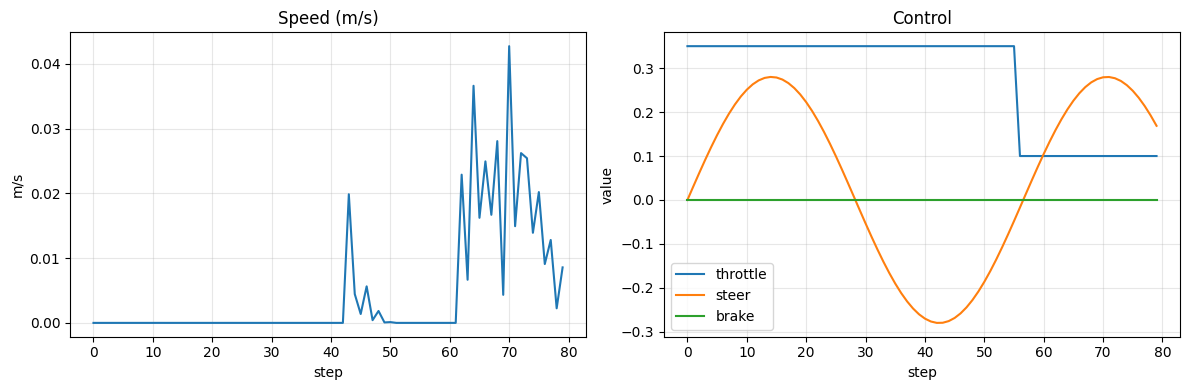

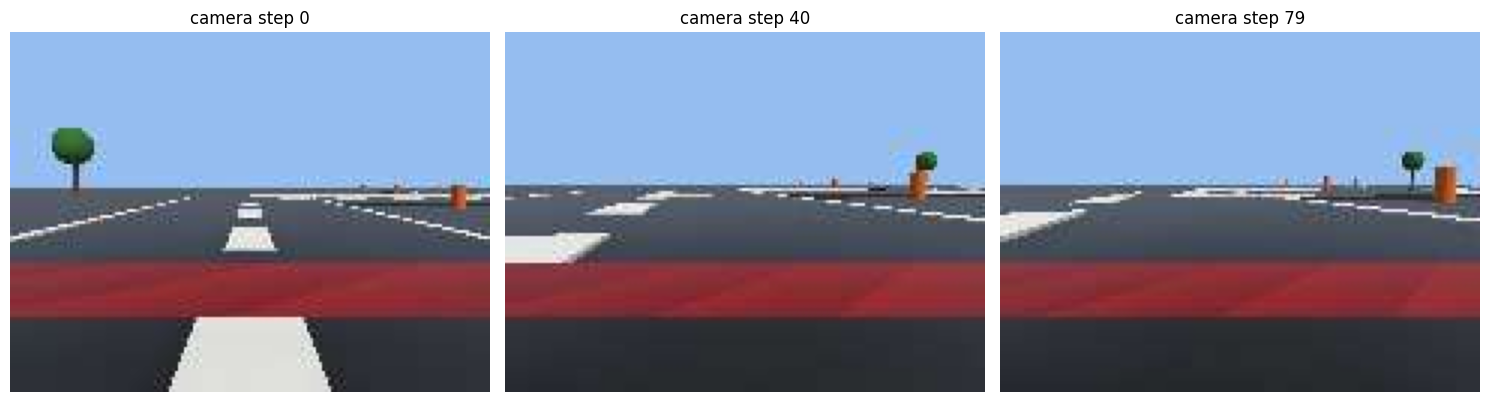

In [3]:
def decode_frame(step_result: dict):
    frame = (step_result or {}).get("frame") or {}
    b64 = frame.get("dataBase64")
    if not isinstance(b64, str) or len(b64) < 16:
        return None
    try:
        raw = base64.b64decode(b64)
        return np.array(Image.open(io.BytesIO(raw)).convert("RGB"))
    except Exception:
        return None

if not api_ready:
    print("Пропуск: API недоступен.")
else:
    records = []
    snapshots = []

    for i in range(RUN_STEPS):
        throttle = 0.35 if i < int(RUN_STEPS * 0.7) else 0.10
        steer = 0.28 * np.sin(i / 9.0)
        brake = 0.0

        cmd = {
            "throttle": float(throttle),
            "steer": float(steer),
            "brake": float(brake),
            "extensions": [],
            "timestamp": i,
            "timeBase": "sim_ms",
        }
        step = client.step(cmd)
        state = step.get("state") or {}

        records.append({
            "step": i,
            "speed": float(state.get("speed", 0.0)),
            "throttle": float(throttle),
            "steer": float(steer),
            "brake": float(brake),
        })

        if i in {0, RUN_STEPS // 2, RUN_STEPS - 1}:
            img = decode_frame(step)
            if img is not None:
                snapshots.append((i, img))

        time.sleep(0.03)

    print(f"rollout done: steps={len(records)}, snapshots={len(snapshots)}")

    if records:
        x = np.array([r["step"] for r in records], dtype=float)
        speed = np.array([r["speed"] for r in records], dtype=float)
        thr = np.array([r["throttle"] for r in records], dtype=float)
        ste = np.array([r["steer"] for r in records], dtype=float)
        brk = np.array([r["brake"] for r in records], dtype=float)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(x, speed)
        axes[0].set_title("Speed (m/s)")
        axes[0].set_xlabel("step")
        axes[0].set_ylabel("m/s")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(x, thr, label="throttle")
        axes[1].plot(x, ste, label="steer")
        axes[1].plot(x, brk, label="brake")
        axes[1].set_title("Control")
        axes[1].set_xlabel("step")
        axes[1].set_ylabel("value")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    if snapshots:
        fig, axes = plt.subplots(1, len(snapshots), figsize=(5 * len(snapshots), 4))
        if len(snapshots) == 1:
            axes = [axes]
        for ax, (idx, img) in zip(axes, snapshots):
            ax.imshow(img)
            ax.set_title(f"camera step {idx}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()


## 3) Быстрые ручные команды (опционально)

Запускай ячейку и меняй значения, если хочешь вручную проверить реакцию симулятора.


state: {'speed': 3.517603772706934e-07, 'position': None, 'heading': None}


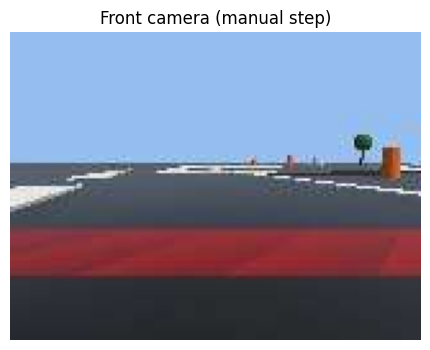

In [4]:
# Один ручной шаг
manual = {
    "throttle": 0.25,
    "steer": 0.15,
    "brake": 0.0,
    "extensions": [],
    "timestamp": 0,
    "timeBase": "sim_ms",
}

if not api_ready:
    print("Пропуск: API недоступен.")
else:
    step = client.step(manual)
    state = step.get("state") or {}
    print("state:", {
        "speed": state.get("speed"),
        "position": state.get("position"),
        "heading": state.get("heading"),
    })
    img = decode_frame(step)
    if img is not None:
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title("Front camera (manual step)")
        plt.axis("off")
        plt.show()
    else:
        print("Кадр камеры не получен в этом шаге.")
